# Write your own generator

The built-in generators cover a wide span of processes, but you will sometimes need a data-generating process they do not produce. `BaseGenerator` exists for that: subclass it, implement one method, and your generator inherits timestamp handling, reproducible seeding, parallel generation, pattern injection (changepoints, anomalies, missingness), exogenous variables, and every dataframe backend.

This guide builds a small logistic-growth ("S-curve") generator, a shape none of the built-ins produce directly.

:::: {.callout-note}
## The contract

A generator needs three things:

1. Subclass `BaseGenerator`.
2. Declare its parameters as Pydantic `Field` attributes.
3. Implement `generate_single_series(self, length: int) -> np.ndarray`, returning one series of the requested length. Draw randomness from `self.rng` so seeding and parallel generation stay deterministic.

Everything else is inherited.
::::

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from pydantic import Field

from synforecast.base import BaseGenerator


class LogisticGrowthGenerator(BaseGenerator):
    """S-curve (logistic) growth with additive observation noise.

    y_t = capacity / (1 + exp(-growth_rate * (t - t_mid))) + noise, with the
    inflection point t_mid placed at ``midpoint_fraction`` of the series
    length. A reasonable model for adoption curves and saturating demand.
    """

    capacity: float = Field(
        default=1000.0, gt=0, description="Saturation level the curve approaches"
    )
    growth_rate: float = Field(
        default=0.1, gt=0, description="Steepness of the transition"
    )
    midpoint_fraction: float = Field(
        default=0.5,
        ge=0.0,
        le=1.0,
        description="Inflection point as a fraction of the series length",
    )
    noise_std: float = Field(
        default=10.0, ge=0, description="Standard deviation of additive noise"
    )

    def generate_single_series(self, length: int) -> np.ndarray:
        t = np.arange(length)
        t_mid = self.midpoint_fraction * length
        curve = self.capacity / (1.0 + np.exp(-self.growth_rate * (t - t_mid)))
        noise = self.rng.normal(0.0, self.noise_std, size=length)
        return curve + noise

## What you implement, and what you get

`generate_single_series` is the only required method. It receives a target `length` — which varies per series between `min_length` and `max_length` — and returns a plain NumPy array. The base class attaches timestamps derived from `freq`, assigns the `unique_id`/`ds`/`y` columns, applies any requested pattern injection, and materializes the result in the chosen dataframe backend. The generator is a Pydantic model, so the shared parameters (`min_length`, `freq`, `seed`, `engine`, and the injection controls) are available without redeclaring them.

## Generate a panel

In [ ]:
generator = LogisticGrowthGenerator(
    min_length=100,
    max_length=160,
    freq="D",
    capacity=1000.0,
    growth_rate=0.08,
    noise_std=15.0,
    seed=0,
)
df = generator.generate(n_series=4)
df.head()

,unique_id,ds,y
0,0,2000-01-01,23.631764
1,0,2000-01-02,-0.870651
2,0,2000-01-03,10.503541
3,0,2000-01-04,-0.730577
4,0,2000-01-05,-21.566003


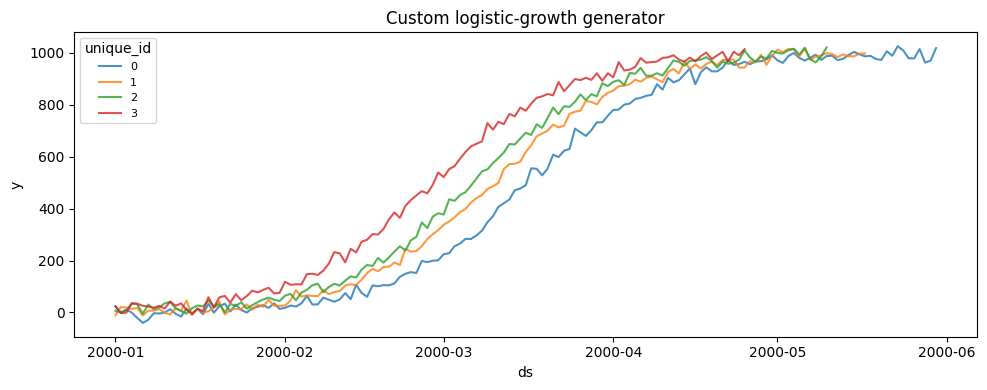

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for uid, series in df.groupby("unique_id", observed=True):
    ax.plot(series["ds"], series["y"], alpha=0.8, label=str(uid))
ax.set(title="Custom logistic-growth generator", xlabel="ds", ylabel="y")
ax.legend(fontsize=8, title="unique_id")
plt.tight_layout()
plt.show()

## Pattern injection is inherited

Because changepoint, anomaly, and missingness injection live in `BaseGenerator`, they work on the custom generator with no extra code: enabling them is a matter of setting the same parameters the built-in generators use. Below the S-curve is generated with injected spikes and dips and a level changepoint, and the ground-truth `anomaly_flag` column is requested through `ExogenousConfig` so the injected points can be marked.

In [ ]:
from synforecast.exogenous import ExogenousConfig

messy = LogisticGrowthGenerator(
    min_length=160,
    max_length=160,
    freq="D",
    capacity=1000.0,
    growth_rate=0.08,
    noise_std=10.0,
    anomalies=True,
    anomaly_fraction=0.04,
    anomaly_types=["spike", "dip"],
    spike_magnitude=150.0,
    dip_magnitude=-150.0,
    changepoints=True,
    num_changepoints=1,
    changepoint_type="level",
    exogenous=ExogenousConfig(anomaly_flags=True),
    engine="polars",
    seed=1,
)
messy_df = messy.generate(n_series=1)
messy_df.columns

['unique_id', 'ds', 'y', 'anomaly_flag']

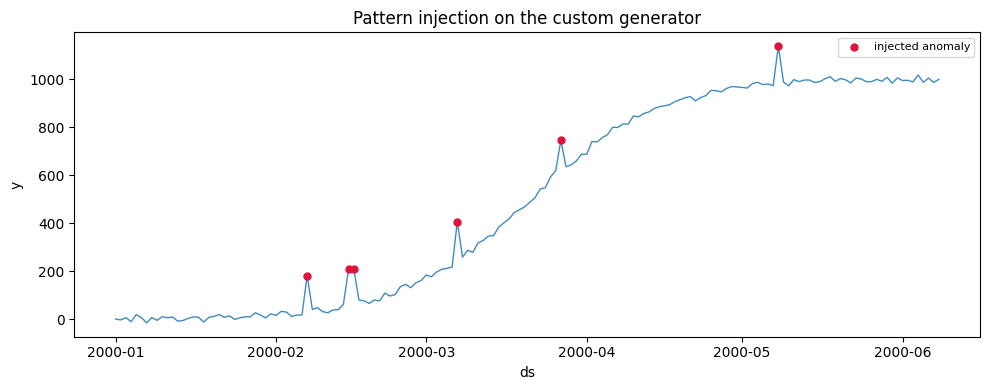

In [ ]:
series = messy_df.sort("ds")
hits = series.filter(pl.col("anomaly_flag") == 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(series["ds"], series["y"], linewidth=1, alpha=0.85)
ax.scatter(hits["ds"], hits["y"], color="crimson", s=25, zorder=3, label="injected anomaly")
ax.set(title="Pattern injection on the custom generator", xlabel="ds", ylabel="y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

:::: {.callout-tip}
## Draw from `self.rng`, not `np.random`

`self.rng` is a seeded NumPy `Generator`. Using it is what lets a fixed `seed` reproduce identical output and keeps parallel generation deterministic. Each series is generated with its own derived RNG state, so series differ from one another while the whole panel stays reproducible.
::::

## Contributing a generator back

To ship a generator as part of SynForecast rather than defining it inline, follow the same layout as the built-ins:

1. Add the module under `synforecast/generators/`.
2. Export the class from `synforecast/generators/__init__.py`.
3. Add tests under `tests/`, and a page under `nbs/docs/generators/<category>/`.

See [CONTRIBUTING](https://github.com/Nixtla/synforecast/blob/main/CONTRIBUTING.md) and the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md) for the conventions and verification expectations.

## Related

- [Changepoints](changepoints), [anomalies](anomalies), and [missingness](missingness) — the injection this generator inherits.
- [Exogenous variables](exogenous) — datetime features, correlated regressors, and the ground-truth flags used above.
- [Compose a dataset](dataset) — combine your generator with others in a `SynSet`.